In [236]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from PIL import Image
import os

In [ ]:
ZOOM = 'no'
cut_value=0.5
y_min_real=-15.0
y_max_real=15.0
z_min_real=54.
z_max_real=75.

## Leitura do arquivo mesh

In [238]:
with open('mesh_piscina','r') as f:  # abrindo o arquivo mesh
    lines = f.readlines()            # lendo as linhas do arquivo

for i in range(len(lines)):               # procurando a linha 'Mesh Tally Number'
    if 'Mesh Tally Number' in lines[i]:    
        tally_location = i           
        break

x_value = []                          # lista para armazenar x

x_length = lines[tally_location + 4].split() 
# lendo os valores de x e tranformando em string serparados pelos espaços em branco
x_length = x_length[2:]     # ignorando os dois prmeiros valores

for j in range(len(x_length)-1):
    x_m = (float(x_length[j])+ float(x_length[j+1]))/2 # calculando o ponto médio
    x_value.append(x_m)  

# repitindo o processo para y e z só que sem determinar o ponto médio
y_length = lines[tally_location + 5].split()        
y_length = y_length[2:]

z_length = lines[tally_location + 6].split()
z_length = z_length[2:]

# definindo onde começa os pontos do tally
start = tally_location + 10
end = start + (len(x_length)-1)*(len(y_length)-1)*(len(z_length)-1) # menos 1 porque é o número de intervalos!!!!

x_origin = len(x_length)/2
y_origin = len(y_length)/2
z_origin = len(z_length)/2

tally_data = lines[start:end] # salvando dados do tally

## Sem ZOOM

In [239]:
if ZOOM == 'no' or ZOOM == 'NO':
    # definindo os valores min max e tranformando em float
    x_min = float(x_length[0])
    x_max = float(x_length[len(x_length)-1])
    y_min = float(y_length[0])
    y_max = float(y_length[len(y_length)-1])
    z_min = float(z_length[0])
    z_max = float(z_length[len(z_length)-1])
    values = []

    # Corrigindo o loop - precisa iterar sobre tally_data, não lines
    for line in tally_data:
        if float(line.split()[0]) == cut_value:
            flux = line.split()[3]                    # pegando os valores de fluxo
            flux = float(flux)                        # trans float

            variance = line.split()[4]
            variance = float(variance)

            if variance > 0.5 or flux == 0.0:  # tirando flux 0 e variancia maior que 50%
                values.append(np.nan)
            else:
                values.append(flux)

    values = np.array(values)
    values = np.reshape(values, (len(y_length)-1, len(z_length)-1)) # transformando os dados em 2d yz

    # Definindo valores auxiliares para zoom
    y_min_aux = y_min_real
    y_max_aux = y_max_real
    z_min_aux = z_min_real
    z_max_aux = z_max_real

    # Inicializando variáveis antes dos loops
    v_min = 0
    v_max = 0
    w_min = 0
    w_max = 0

    # essa parte é para introduzir o zoom
    for v in range(len(y_length)):
        if float(y_length[v]) == y_min_aux:
            v_min = v
        if float(y_length[v]) == y_max_aux:
            v_max = v
    
    if (v_max + v_min)//2 != 0: 
        if v_max + 1 < len(y_length):  # Verificação de limites
            v_max += 1  # adiciona mais 1 v_max para pegar o ultimo valor
            y_max = float(y_length[v_max])
    
    for w in range(len(z_length)):
        if float(z_length[w]) == z_min_aux:
            w_min = w
        if float(z_length[w]) == z_max_aux:
            w_max = w
    
    if (w_max + w_min)//2 != 0:
        if w_max + 1 < len(z_length):  # Verificação de limites
            w_max += 1 
            z_max = float(z_length[w_max])
    
    cntr_x = int((v_max + v_min)/2)
    cntr_z = int((w_max + w_min)/2)
    delta_x = int(x_origin - cntr_x)
    delta_z = int(z_origin - cntr_z)

# Invertendo os valores de cada linha, essa inversão é necessária para o gráfico ficar com a orientação correta
for i in range(len(values)):
    values[i] = values[i][::-1]

values = np.transpose(values)

if ZOOM=="YES" or ZOOM=="yes":
   values=values[w_max:w_min,v_min:v_max]

## Função que define a transparencia na img

In [240]:
def alpha_proc(img):
# processo para tranformar a parte branca da imagem em transparente
   alpha = np.zeros((len(img), len(img[0]))) 

   for i in range(len(img)):
      for j in range(len(img[i])):
        if img[i][j] > 200:  # valor de corte para definir se é branco
            alpha[i][j] = 0   # colocando como transparente
        else: 
           alpha[i][j] = 1    #  caso contrário opaco
   return alpha


## Abrindo a imagem e aplicando função alpha

In [241]:
def get_outilines(file):
    image = Image.open(file)
    image = np.array(image)
    Ly_img = len(image[0])
    Lz_img = len(image)
    if ZOOM=="YES" or ZOOM=="yes":
        image=image[w_max*Lz_img//len(z_length):w_min*Lz_img//len(z_length),v_min*Ly_img//len(y_length):v_max*Ly_img//len(y_length)]
    image = image[:,:,1]
    alpha = alpha_proc(image)

    return image, alpha

if ZOOM=="NO" or ZOOM=="no":
    x_min_real=x_min
    x_max_real=x_max
    y_min_real=y_min
    y_max_real=y_max
    z_min_real=z_min
    z_max_real=z_max

## Função para mostrar as linhas e definir colormap

In [242]:
def show_outline(outline):  
    plt.imshow(outline[0],cmap="gray", alpha=outline[1] ,extent = [y_min_real, y_max_real, z_min_real, z_max_real])

## Plotando o fmesh

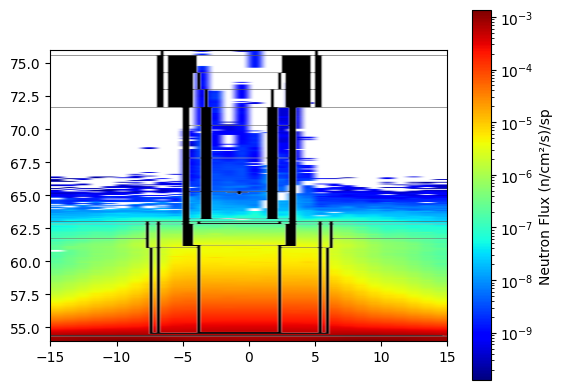

In [243]:
frames = get_outilines('piscina.PNG')

colormap = mpl.colormaps['jet'].copy()
colormap.set_bad(color='white')  

plt.imshow(values,extent = [y_min_real, y_max_real, z_min_real, z_max_real] ,cmap=colormap, norm=LogNorm(vmin=np.nanmin(values), vmax=np.nanmax(values)))

cb = plt.colorbar()
cb.ax.set_ylabel("Neutron Flux (n/cm²/s)/sp")
show_outline(frames)
plt.show()